In [1]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

c:\Users\a\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
df_crowd = pd.read_csv('lim_crowd.csv')
df_expert = pd.read_csv('spinde_expert.csv', sep=";")

In [35]:
df_crowd['row_id'] = df_crowd.index 

df_text = pd.wide_to_long(df_crowd, stubnames=['s'], i='row_id', j='sentence_index').reset_index()[['row_id', 'id_article', 'sentence_index', 's']]

df_text['text'] = df_text['s'].astype(str).str.replace(r'^\[\d+\]:\s*', '', regex=True)
df_text = df_text[df_text['text'] != 'nan']

label_map = {str(i): f"label{i}" for i in range(20)}
df_renamed = df_crowd.rename(columns=label_map)

df_labels = pd.wide_to_long(df_renamed, stubnames=['label'], i='row_id', j='sentence_index').reset_index()[['row_id', 'sentence_index', 'label']]

df_clean = pd.merge(df_text, df_labels, on=['row_id', 'sentence_index'])

same = df_clean.groupby('text')['label'].mean().reset_index()
same['is_biased'] = same['label'].apply(lambda x: 1 if x > 2.5 else 0)

print(f"Total unique sentences: {len(same)}")
print(f"Biased sentences: {same['is_biased'].sum()}")
print(same.head())

# Save for your UMAP script
same.to_csv("Lim_2020_cleaned.csv", index=False)

Total unique sentences: 815
Biased sentences: 171
                                                text  label  is_biased
0  "And the president is very realistic about tha...   1.75          0
1  "And then we can begin to lay out a map, a roa...   1.75          0
2  "As I've told people many times, I will contin...   3.25          1
3  "As a matter of fact, some of this I heard yes...   1.75          0
4  "As far as I'm aware, we've never worked for a...   2.25          0


In [36]:
print(df_expert['label_bias'].value_counts())

spinde_biased = df_expert[df_expert['label_bias'] == 'Biased'].copy()

spinde_clean = spinde_biased[['text']].copy()
spinde_clean['Source'] = 'Expert (Spinde)'

print(spinde_clean['text'].head().values)

spinde_clean.to_csv("Spinde_expert_cleaned.csv", index=False)

label_bias
Non-biased      800
Biased          746
No agreement    154
Name: count, dtype: int64
['The Republican president assumed he was helping the industry at the expense of the environment – a trade-off Trump was happy to make since he rejects climate science anyway. '
 'The tragedy of America’s 18 years in Afghanistan has been a stubborn refusal to admit the Afghan government is incapable of standing on its own, no matter how much money is poured into it, how much training its troops are given, or how many of its battles American soldiers fight.'
 'A review of his posts in online message boards revealed he wanted to plant neo-Nazi propaganda inside Nevada middle and high schools.'
 'Politicians have no business directing or defining patriotism — especially when their rhetoric sounds like 1950s-era Soviet sloganeering.'
 'Last week, Ankara broke the 2015 agreement with Brussels in which it would stop the illegal flow of migrants through Turkey in exchange for money and continuing 

In [37]:
df_lim = pd.read_csv("Lim_2020_cleaned.csv")
lim_biased = df_lim[df_lim['label'] >= 2.5].copy()
lim_biased['Source'] = 'Crowd (Lim)'

spinde_biased = pd.read_csv("Spinde_expert_cleaned.csv")
spinde_biased['Source'] = 'Expert (Spinde)'

df_map = pd.concat([lim_biased[['text', 'Source']], spinde_biased[['text', 'Source']]])

In [38]:
def get_features(text):
    blob = TextBlob(str(text))
    words = blob.words.lower()
    
    subjectivity = blob.sentiment.subjectivity
    
    emotion = abs(blob.sentiment.polarity)
    
    length = len(words)
    
    hedges = ["maybe", "perhaps", "likely", "unlikely", "allegedly","claimed", "apparently", "suggest", "seem", "possibly"]
    hedge_count = sum(1 for w in words if w in hedges)
    
    return pd.Series([subjectivity, emotion, length, hedge_count])

feat_cols = ['Subjectivity', 'Emotion', 'Length', 'Hedges']
df_map[feat_cols] = df_map['text'].apply(get_features)

c:\Users\a\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


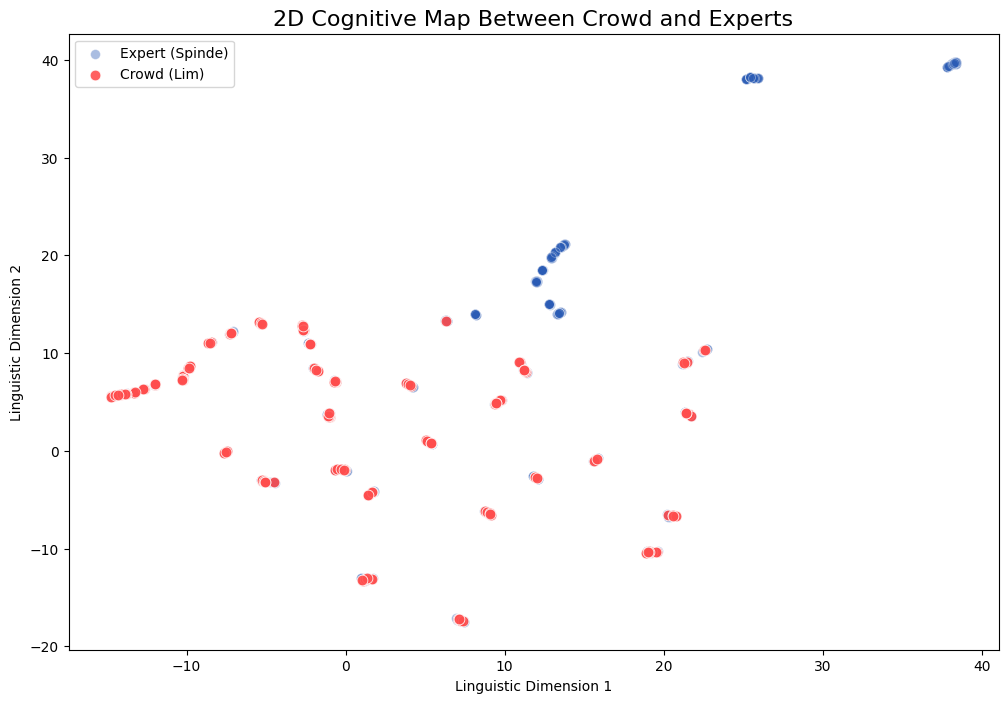


Feature means comparison
                 Subjectivity   Emotion     Length    Hedges
Source                                                      
Crowd (Lim)          0.316235  0.138744  24.887387  0.040541
Expert (Spinde)      0.412343  0.150462  35.879357  0.056300


In [39]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(df_map[feat_cols])

plt.figure(figsize=(12, 8))

sns.scatterplot(x=embedding[df_map['Source']=='Expert (Spinde)', 0], y=embedding[df_map['Source']=='Expert (Spinde)', 1], color='#2b5cb5', alpha=0.4, s=50, label='Expert (Spinde)')

sns.scatterplot(x=embedding[df_map['Source']=='Crowd (Lim)', 0], y=embedding[df_map['Source']=='Crowd (Lim)', 1], color='#ff4d4d', alpha=0.9, s=60, label='Crowd (Lim)')

plt.title("2D Cognitive Map Between Crowd and Experts", fontsize=16)
plt.xlabel("Linguistic Dimension 1")
plt.ylabel("Linguistic Dimension 2")
plt.legend()
plt.show()

print("\nFeature means comparison")
print(df_map.groupby('Source')[feat_cols].mean())

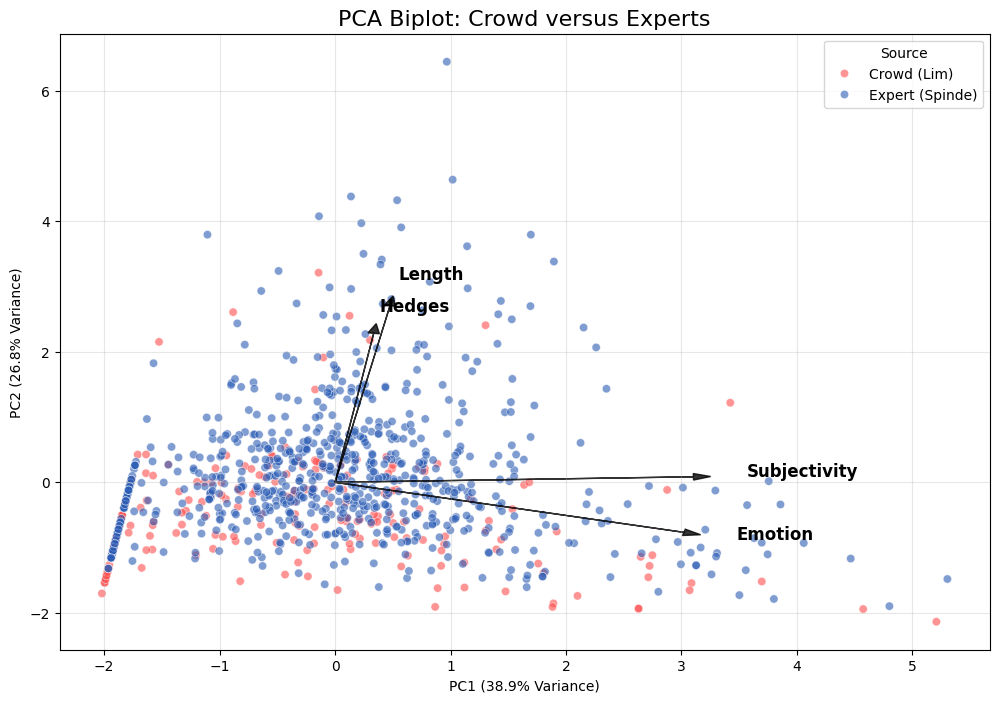


Feature loadings (Correlation with Axes)
     Subjectivity   Emotion    Length    Hedges
PC1      0.710191  0.691319  0.108852  0.076535
PC2      0.023446 -0.211432  0.746798  0.630111


In [40]:
df_pca = pd.concat([lim_biased[['text', 'Source']], spinde_biased[['text', 'Source']]])

df_pca[feat_cols] = df_pca['text'].apply(get_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[feat_cols])

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df_pca['PC1'] = components[:, 0]
df_pca['PC2'] = components[:, 1]

plt.figure(figsize=(12, 8))

sns.scatterplot(x='PC1', y='PC2', hue='Source', data=df_pca, palette={'Crowd (Lim)': '#ff4d4d', 'Expert (Spinde)': '#2b5cb5'}, alpha=0.6)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
arrow_scale = 3.5 

for i, feature in enumerate(feat_cols):
    plt.arrow(0, 0, loadings[i, 0] * arrow_scale, loadings[i, 1] * arrow_scale, color='black', alpha=0.8, head_width=0.1)
    plt.text(loadings[i, 0] * arrow_scale * 1.15, loadings[i, 1] * arrow_scale * 1.15, feature, color='black', fontsize=12, weight='bold')

plt.title("PCA Biplot: Crowd versus Experts", fontsize=16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)")
plt.grid(True, alpha=0.3)
plt.show()

print("\nFeature loadings (Correlation with Axes)")
print(pd.DataFrame(pca.components_, columns=feat_cols, index=['PC1', 'PC2']))

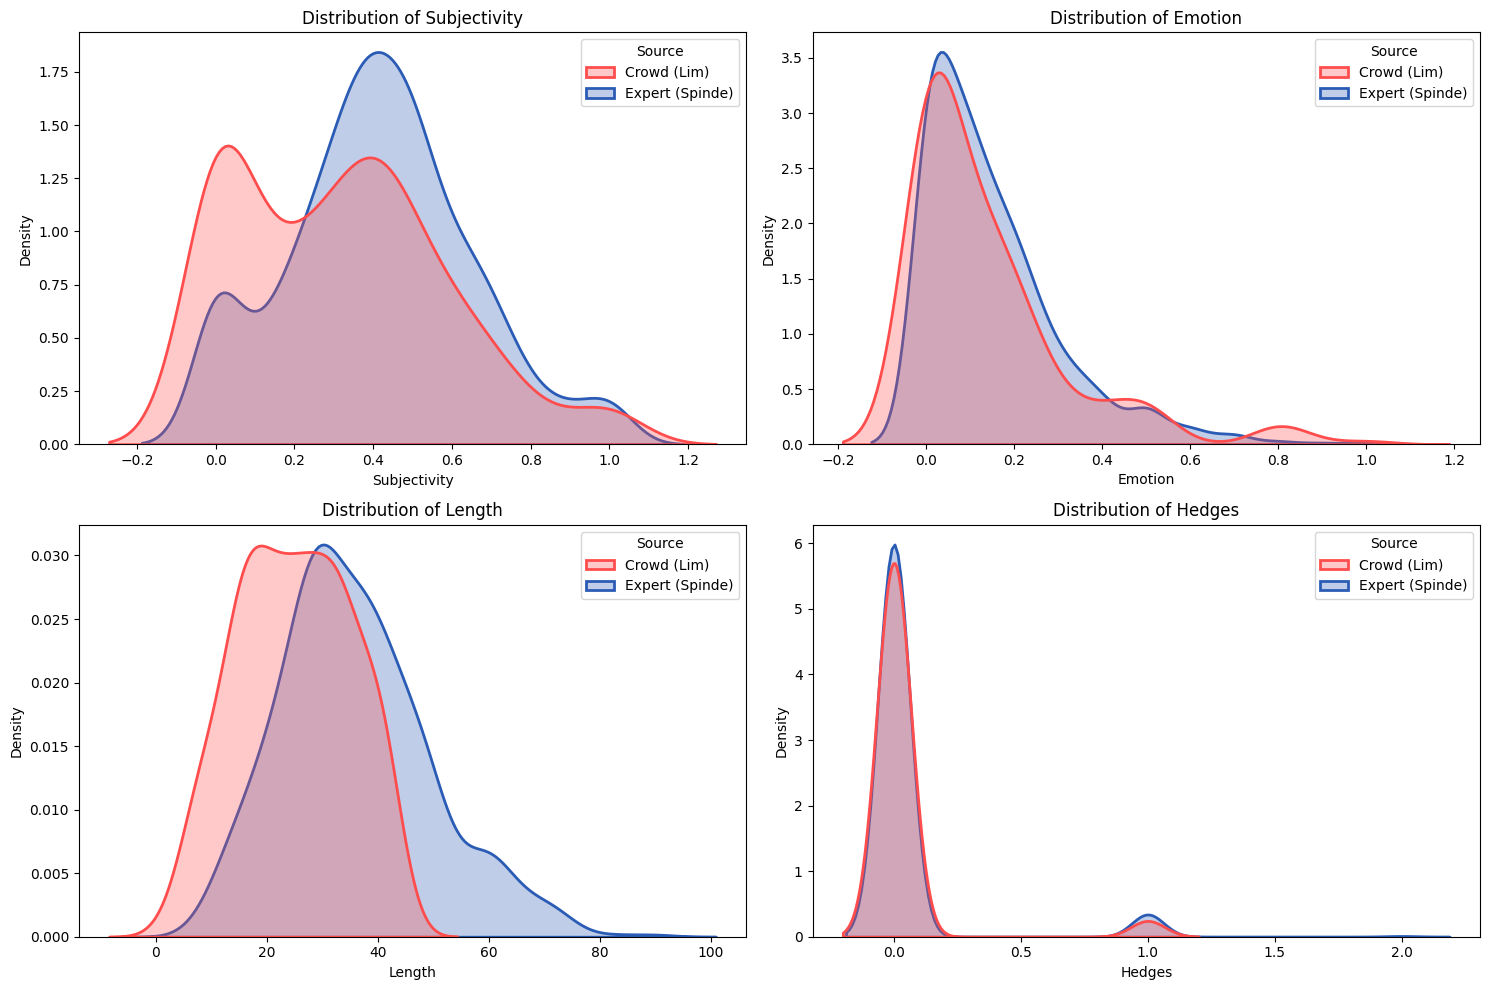

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    sns.kdeplot(data=df_map, x=col, hue='Source', fill=True, common_norm=False, palette={'Crowd (Lim)': '#ff4d4d', 'Expert (Spinde)': '#2b5cb5'}, ax=axes[i], alpha=0.3, linewidth=2)
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

C:\Users\a\AppData\Local\Temp\ipykernel_11692\2004771486.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


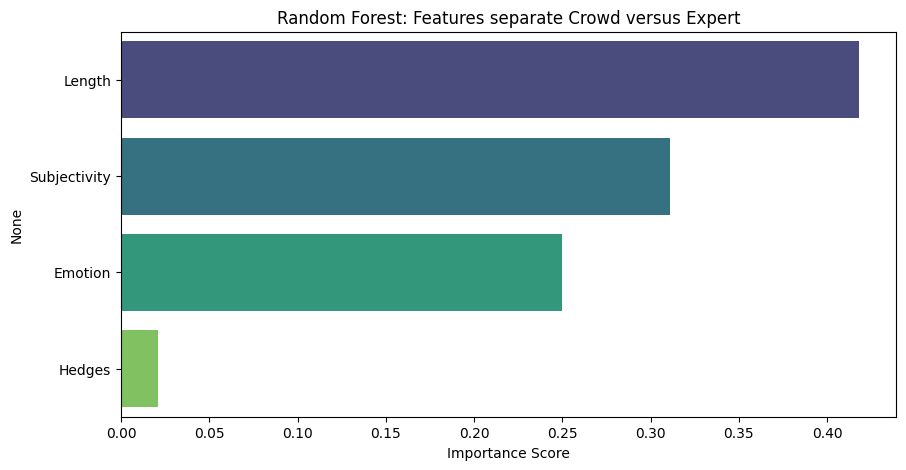

RF accuracy: 0.77

LR directionality
Positive = expert
Negative = crowd
        Feature  Coefficient
2        Length     1.024584
0  Subjectivity     0.358755
3        Hedges    -0.041134
1       Emotion    -0.134985


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

lim_biased['target'] = 0

spinde_biased['target'] = 1

df_all = pd.concat([lim_biased[['text', 'target']], spinde_biased[['text', 'target']]])

X = df_all['text'].apply(get_features)
X.columns = feat_cols
y = df_all['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(10, 5))
importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title("Random Forest: Features separate Crowd versus Expert")
plt.xlabel("Importance Score")
plt.show()

print(f"RF accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

coefs = pd.DataFrame({'Feature': feat_cols, 'Coefficient': logreg.coef_[0]}).sort_values(by='Coefficient', ascending=False)

print("\nLR directionality")
print("Positive = expert")
print("Negative = crowd")
print(coefs)